# Convolutional Neural Network (CNN) Architectures for Brain Tumor Detection from MRI with Augmented Generalization

**About the Brain MRI Images dataset:**<br>
The dataset contains 2 folders: yes and no which contains 253 Brain MRI Images. The folder yes contains 155 Brain MRI Images that are tumorous and the folder no contains 98 Brain MRI Images that are non-tumorous. You can find it [here](https://www.kaggle.com/navoneel/brain-mri-images-for-brain-tumor-detection).

## Import Necessary Packages

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Input, ZeroPadding2D, BatchNormalization, Activation, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils import shuffle
import cv2
import imutils
import numpy as np
import matplotlib.pyplot as plt
import time
from os import listdir

%matplotlib inline

## Data Preparation & Preprocessing

In [2]:
def crop_brain_contour(image, plot=False):
    
    #import imutils
    #import cv2
    #from matplotlib import pyplot as plt
    
    # Convert the image to grayscale, and blur it slightly
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # Threshold the image, then perform a series of erosions +
    # dilations to remove any small regions of noise
    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    # Find contours in thresholded image, then grab the largest one
    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key=cv2.contourArea)
    

    # Find the extreme points
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])
    
    # crop new image out of the original image using the four extreme points (left, right, top, bottom)
    new_image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]]            

    if plot:
        plt.figure()

        plt.subplot(1, 2, 1)
        plt.imshow(image)
        
        plt.tick_params(axis='both', which='both', 
                        top=False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)
        
        plt.title('Original Image')
            
        plt.subplot(1, 2, 2)
        plt.imshow(new_image)

        plt.tick_params(axis='both', which='both', 
                        top=False, bottom=False, left=False, right=False,
                        labelbottom=False, labeltop=False, labelleft=False, labelright=False)

        plt.title('Cropped Image')
        
        plt.show()
    
    return new_image

In order to better understand what it's doing, let's grab an image from the dataset and apply this cropping function to see the result:

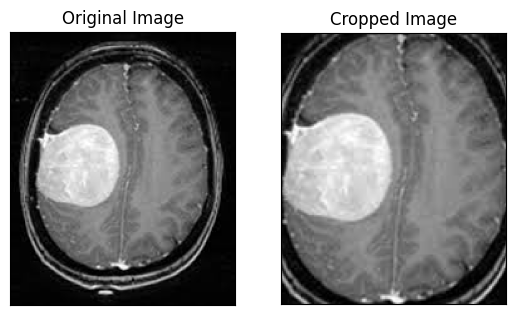

In [3]:
ex_img = cv2.imread('yes/Y1.jpg')
ex_new_img = crop_brain_contour(ex_img, True)

### Load up the data:

The following function takes two arguments, the first one is a list of directory paths for the folders 'yes' and 'no' that contain the image data and the second argument is the image size, and for every image in both directories and does the following: 
1. Read the image.
2. Crop the part of the image representing only the brain.
3. Resize the image (because the images in the dataset come in different sizes (meaning width, height and # of channels). So, we want all of our images to be (240, 240, 3) to feed it as an input to the neural network.
4. Apply normalization because we want pixel values to be scaled to the range 0-1.
5. Append the image to <i>X</i> and its label to <i>y</i>.<br>

After that, Shuffle <i>X</i> and <i>y</i>, because the data is ordered (meaning the arrays contains the first part belonging to one class and the second part belonging to the other class, and we don't want that).<br>
Finally, Return <i>X</i> and <i>y</i>.

In [4]:
def load_data(dir_list, image_size):
    """
    Read images, resize and normalize them. 
    Arguments:
        dir_list: list of strings representing file directories.
    Returns:
        X: A numpy array with shape = (#_examples, image_width, image_height, #_channels)
        y: A numpy array with shape = (#_examples, 1)
    """

    # load all images in a directory
    X = []
    y = []
    image_width, image_height = image_size
    
    for directory in dir_list:
        for filename in listdir(directory):
            # load the image
            image = cv2.imread(directory + '\\' + filename)
            # crop the brain and ignore the unnecessary rest part of the image
            image = crop_brain_contour(image, plot=False)
            # resize image
            image = cv2.resize(image, dsize=(image_width, image_height), interpolation=cv2.INTER_CUBIC)
            # normalize values
            image = image / 255.
            # convert image to numpy array and append it to X
            X.append(image)
            # append a value of 1 to the target array if the image
            # is in the folder named 'yes', otherwise append 0.
            if directory[-3:] == 'yes':
                y.append([1])
            else:
                y.append([0])
                
    X = np.array(X)
    y = np.array(y)
    
    # Shuffle the data
    X, y = shuffle(X, y)
    
    print(f'Number of examples is: {len(X)}')
    print(f'X shape is: {X.shape}')
    print(f'y shape is: {y.shape}')
    
    return X, y

Load up the data that we augmented earlier in the Data Augmentation notebook.<br>
**Note:** the augmented data directory contains not only the new generated images but also the original images.

In [6]:
augmented_path = 'augmented data/'

# augmented data (yes and no) contains both the original and the new generated examples
augmented_yes = augmented_path + 'yes' 
augmented_no = augmented_path + 'no'

IMG_WIDTH, IMG_HEIGHT = (240, 240)

def load_data(dir_list, image_size):
    X = []
    y = []
    image_width, image_height = image_size

    for directory in dir_list:
        for filename in listdir(directory):
            image = cv2.imread(directory + '\\' + filename)
            image = crop_brain_contour(image, plot=False)
            image = cv2.resize(image, dsize=(image_width, image_height), interpolation=cv2.INTER_CUBIC)
            image = image / 255.
            X.append(image)
            y.append([1] if directory[-3:] == 'yes' else [0])

    X = np.array(X)
    y = np.array(y)
    X, y = shuffle(X, y)

    print(f'Number of examples is: {len(X)}')
    print(f'X shape is: {X.shape}')
    print(f'y shape is: {y.shape}')

    return X, y

# Reduce memory usage: smaller images + float32 + optional cap per class
IMG_WIDTH, IMG_HEIGHT = (128, 128)
MAX_IMAGES_PER_CLASS = 3000

def load_data(dir_list, image_size, max_per_class=None):
    X = []
    y = []
    image_width, image_height = image_size

    for directory in dir_list:
        files = listdir(directory)
        if max_per_class is not None:
            files = files[:max_per_class]

        for filename in files:
            image = cv2.imread(directory + '\\' + filename)
            if image is None:
                continue

            image = crop_brain_contour(image, plot=False)
            image = cv2.resize(image, dsize=(image_width, image_height), interpolation=cv2.INTER_AREA)
            image = image.astype(np.float32) / 255.0

            X.append(image)
            y.append([1] if directory.endswith('yes') else [0])

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.uint8)
    X, y = shuffle(X, y, random_state=42)

    print(f'Number of examples is: {len(X)}')
    print(f'X shape is: {X.shape}, dtype: {X.dtype}')
    print(f'y shape is: {y.shape}, dtype: {y.dtype}')

    return X, y

X, y = load_data([augmented_yes, augmented_no], (IMG_WIDTH, IMG_HEIGHT), max_per_class=MAX_IMAGES_PER_CLASS)

Number of examples is: 6000
X shape is: (6000, 128, 128, 3), dtype: float32
y shape is: (6000, 1), dtype: uint8


As we see, we have 2065 images. Each images has a shape of **(240, 240, 3)=(image_width, image_height, number_of_channels)**

### Plot sample images:

In [7]:
def plot_sample_images(X, y, n=50):
    """
    Plots n sample images for both values of y (labels).
    Arguments:
        X: A numpy array with shape = (#_examples, image_width, image_height, #_channels)
        y: A numpy array with shape = (#_examples, 1)
    """
    
    for label in [0,1]:
        # grab the first n images with the corresponding y values equal to label
        images = X[np.argwhere(y == label)]
        n_images = images[:n]
        
        columns_n = 10
        rows_n = int(n/ columns_n)

        plt.figure(figsize=(20, 10))
        
        i = 1 # current plot        
        for image in n_images:
            plt.subplot(rows_n, columns_n, i)
            plt.imshow(image[0])
            
            # remove ticks
            plt.tick_params(axis='both', which='both', 
                            top=False, bottom=False, left=False, right=False,
                           labelbottom=False, labeltop=False, labelleft=False, labelright=False)
            
            i += 1
        
        label_to_str = lambda label: "Yes" if label == 1 else "No"
        plt.suptitle(f"Brain Tumor: {label_to_str(label)}")
        plt.show()

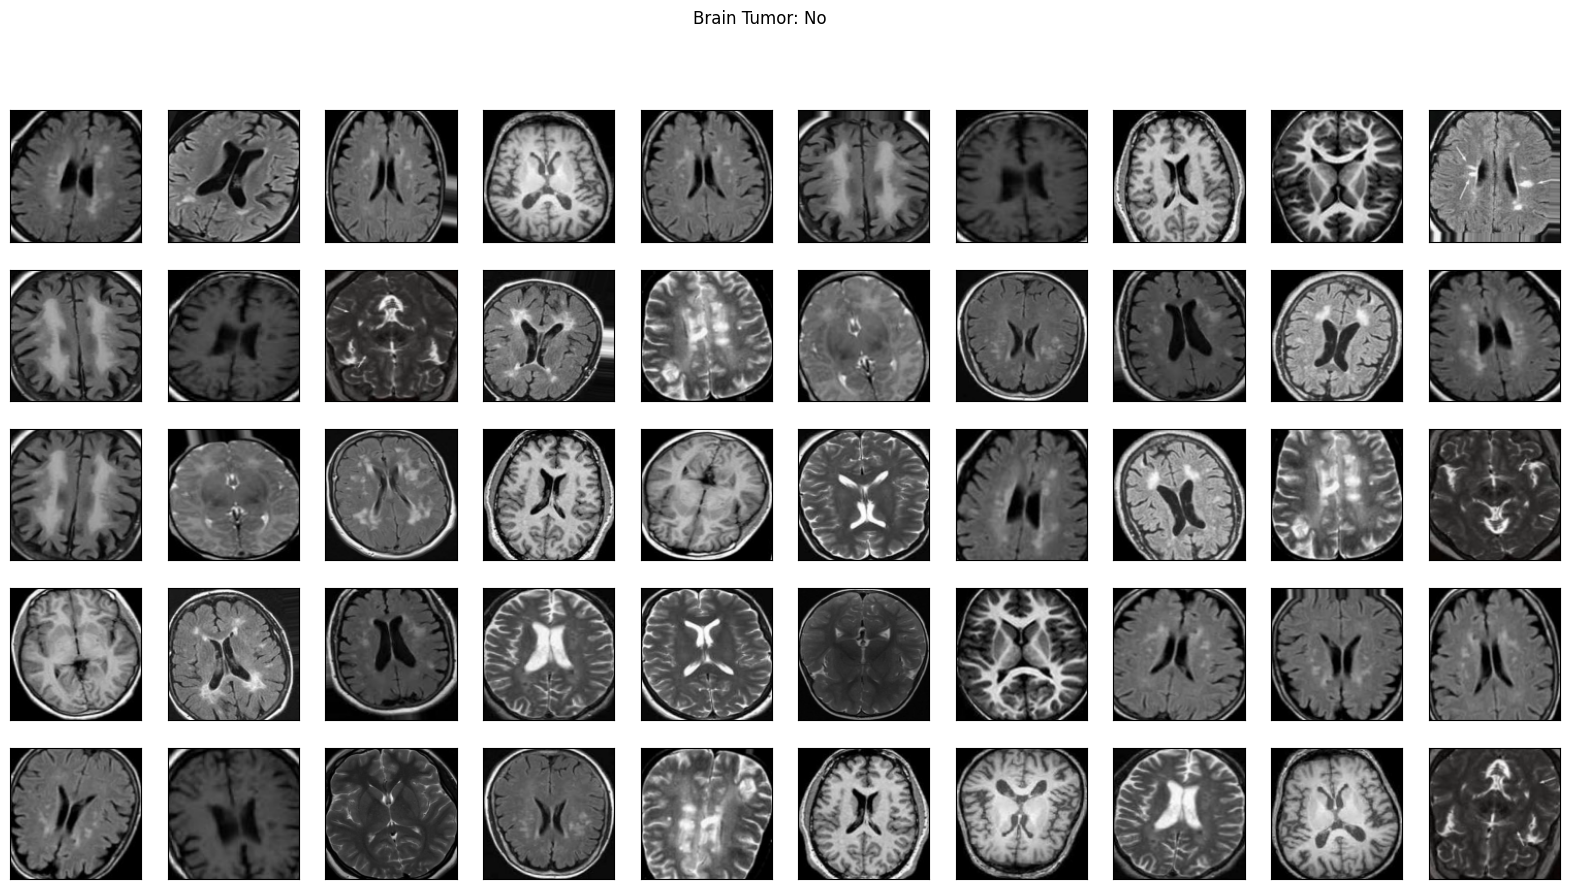

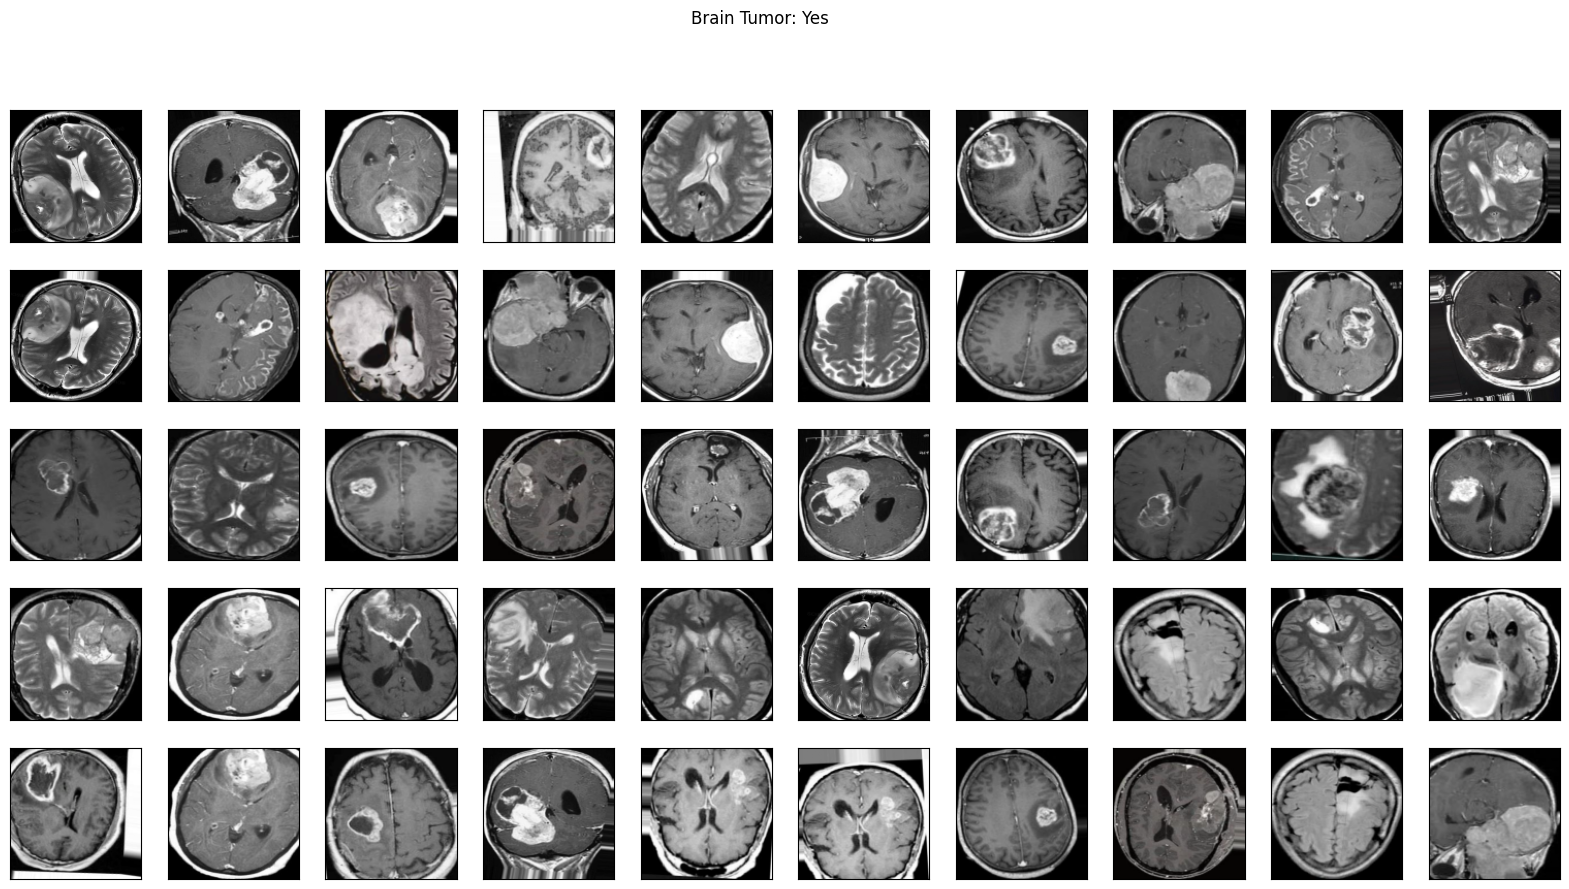

In [8]:
plot_sample_images(X, y)

### Split the data:
Split <i>X</i> and <i>y</i> into training, validation (development) and validation sets.

In [9]:
def split_data(X, y, test_size=0.2):
       
    """
    Splits data into training, development and test sets.
    Arguments:
        X: A numpy array with shape = (#_examples, image_width, image_height, #_channels)
        y: A numpy array with shape = (#_examples, 1)
    Returns:
        X_train: A numpy array with shape = (#_train_examples, image_width, image_height, #_channels)
        y_train: A numpy array with shape = (#_train_examples, 1)
        X_val: A numpy array with shape = (#_val_examples, image_width, image_height, #_channels)
        y_val: A numpy array with shape = (#_val_examples, 1)
        X_test: A numpy array with shape = (#_test_examples, image_width, image_height, #_channels)
        y_test: A numpy array with shape = (#_test_examples, 1)
    """
    
    X_train, X_test_val, y_train, y_test_val = train_test_split(X, y, test_size=test_size)
    X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val, test_size=0.5)
    
    return X_train, y_train, X_val, y_val, X_test, y_test

Let's use the following way to split:<br>
1. 70% of the data for training.
2. 15% of the data for validation.
3. 15% of the data for testing.

In [10]:
X_train, y_train, X_val, y_val, X_test, y_test = split_data(X, y, test_size=0.3)

In [11]:
print ("number of training examples = " + str(X_train.shape[0]))
print ("number of development examples = " + str(X_val.shape[0]))
print ("number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(y_train.shape))
print ("X_val (dev) shape: " + str(X_val.shape))
print ("Y_val (dev) shape: " + str(y_val.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(y_test.shape))

number of training examples = 4200
number of development examples = 900
number of test examples = 900
X_train shape: (4200, 128, 128, 3)
Y_train shape: (4200, 1)
X_val (dev) shape: (900, 128, 128, 3)
Y_val (dev) shape: (900, 1)
X_test shape: (900, 128, 128, 3)
Y_test shape: (900, 1)


Some helper functions:

In [12]:
# Nicely formatted time string
def hms_string(sec_elapsed):
    h = int(sec_elapsed / (60 * 60))
    m = int((sec_elapsed % (60 * 60)) / 60)
    s = sec_elapsed % 60
    return f"{h}:{m}:{round(s,1)}"

In [14]:
def compute_f1_score(y_true, prob):
    # convert the vector of probabilities to a target vector
    y_pred = np.where(prob > 0.5, 1, 0)
    
    score = f1_score(y_true, y_pred)
    
    return score

# Build the model

Let's build a convolutional neural network model:

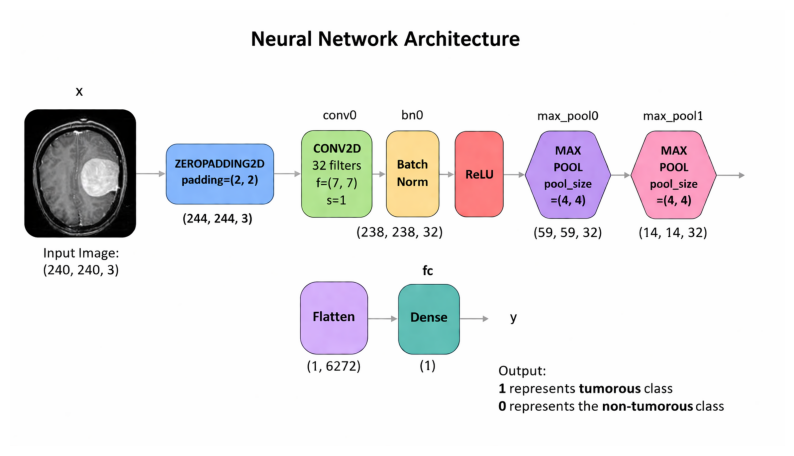

In [68]:
from IPython.display import display
import os

img_path = 'architecture.png'
if not os.path.exists(img_path):
    print(f"File not found: {img_path}")
else:
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,8))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [15]:
def build_model(input_shape):
    """
    Arugments:
        input_shape: A tuple representing the shape of the input of the model. shape=(image_width, image_height, #_channels)
    Returns:
        model: A Model object.
    """
    # Define the input placeholder as a tensor with shape input_shape. 
    X_input = Input(input_shape) # shape=(?, 240, 240, 3)
    
    # Zero-Padding: pads the border of X_input with zeroes
    X = ZeroPadding2D((2, 2))(X_input) # shape=(?, 244, 244, 3)
    
    # CONV -> BN -> RELU Block applied to X
    X = Conv2D(32, (7, 7), strides = (1, 1), name = 'conv0')(X)
    X = BatchNormalization(axis = 3, name = 'bn0')(X)
    X = Activation('relu')(X) # shape=(?, 238, 238, 32)
    
    # MAXPOOL
    X = MaxPooling2D((4, 4), name='max_pool0')(X) # shape=(?, 59, 59, 32) 
    
    # MAXPOOL
    X = MaxPooling2D((4, 4), name='max_pool1')(X) # shape=(?, 14, 14, 32)
    
    # FLATTEN X 
    X = Flatten()(X) # shape=(?, 6272)
    # FULLYCONNECTED
    X = Dense(1, activation='sigmoid', name='fc')(X) # shape=(?, 1)
    
    # Create model. This creates your Keras model instance, you'll use this instance to train/test the model.
    model = Model(inputs = X_input, outputs = X, name='BrainDetectionModel')
    
    return model

Define the image shape:

In [16]:
IMG_SHAPE = (IMG_WIDTH, IMG_HEIGHT, 3)

In [17]:
model = build_model(IMG_SHAPE)

In [18]:
model.summary()

Model: "BrainDetectionModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ (None, 132, 132, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv0 (Conv2D)                  │ (None, 126, 126, 32)   │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn0 (BatchNormalization)        │ (None, 126, 126, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool0 (MaxPooling2D)        │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1 (MaxPooling2D)        │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 1)              │         1,569 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,433 (25.13 KB)

 Trainable params: 6,369 (24.88 KB)

 Non-trainable params: 64 (256.00 B)

Compile the model:

In [19]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [20]:
# tensorboard
log_file_name = f'brain_tumor_detection_cnn_{int(time.time())}'
tensorboard = TensorBoard(log_dir=f'logs/{log_file_name}')

In [28]:
# checkpoint
# unique file name that will include the epoch and the validation (development) accuracy
# use 'val_accuracy' since Keras provides that key in logs
filepath="cnn-parameters-improvement-{epoch:02d}-{val_accuracy:.2f}"
# save the model with the best validation (development) accuracy till now
checkpoint = ModelCheckpoint(
    filepath=f"models/{filepath}.keras",
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max',
)

## Train the model

In [29]:
start_time = time.time()

model.fit(
    x=X_train,
    y=y_train,
    batch_size=32,
    epochs=10,
    validation_data=(X_val, y_val),
    callbacks=[tensorboard, checkpoint]
)

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.8590 - loss: 0.3225
Epoch 1: val_accuracy improved from None to 0.87222, saving model to models/cnn-parameters-improvement-01-0.87.keras

Epoch 1: finished saving model to models/cnn-parameters-improvement-01-0.87.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 45s 344ms/step - accuracy: 0.8762 - loss: 0.3014 - val_accuracy: 0.8722 - val_loss: 0.3354
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.8916 - loss: 0.2716
Epoch 2: val_accuracy did not improve from 0.87222
132/132 ━━━━━━━━━━━━━━━━━━━━ 36s 268ms/step - accuracy: 0.8905 - loss: 0.2652 - val_accuracy: 0.7844 - val_loss: 0.4398
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.9142 - loss: 0.2218
Epoch 3: val_accuracy improved from 0.87222 to 0.91000, saving model to models/cnn-parameters-improvement-03-0.91.keras

Epoch 3: finished saving model to models/cnn-parameters-improvement-03-0.91.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 36s 274ms/ste

Let's train for a few more epochs:

In [30]:
start_time = time.time()

model.fit(x=X_train, y=y_train, batch_size=32, epochs=3, validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint])

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

Epoch 1/3
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.9566 - loss: 0.1239
Epoch 1: val_accuracy improved from 0.94222 to 0.95333, saving model to models/cnn-parameters-improvement-01-0.95.keras

Epoch 1: finished saving model to models/cnn-parameters-improvement-01-0.95.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 39s 291ms/step - accuracy: 0.9610 - loss: 0.1171 - val_accuracy: 0.9533 - val_loss: 0.1411
Epoch 2/3
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.9635 - loss: 0.1144
Epoch 2: val_accuracy did not improve from 0.95333
132/132 ━━━━━━━━━━━━━━━━━━━━ 38s 285ms/step - accuracy: 0.9619 - loss: 0.1147 - val_accuracy: 0.7444 - val_loss: 0.6346
Epoch 3/3
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.9659 - loss: 0.1030
Epoch 3: val_accuracy improved from 0.95333 to 0.95889, saving model to models/cnn-parameters-improvement-03-0.96.keras

Epoch 3: finished saving model to models/cnn-parameters-improvement-03-0.96.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 37s 283ms/ste

In [31]:
start_time = time.time()

model.fit(x=X_train, y=y_train, batch_size=32, epochs=3, validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint])

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

Epoch 1/3
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.9706 - loss: 0.0936
Epoch 1: val_accuracy improved from 0.95889 to 0.96444, saving model to models/cnn-parameters-improvement-01-0.96.keras

Epoch 1: finished saving model to models/cnn-parameters-improvement-01-0.96.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 38s 282ms/step - accuracy: 0.9731 - loss: 0.0907 - val_accuracy: 0.9644 - val_loss: 0.1331
Epoch 2/3
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.9714 - loss: 0.0860
Epoch 2: val_accuracy did not improve from 0.96444
132/132 ━━━━━━━━━━━━━━━━━━━━ 39s 298ms/step - accuracy: 0.9702 - loss: 0.0907 - val_accuracy: 0.9533 - val_loss: 0.1253
Epoch 3/3
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.9561 - loss: 0.1090
Epoch 3: val_accuracy did not improve from 0.96444
132/132 ━━━━━━━━━━━━━━━━━━━━ 41s 298ms/step - accuracy: 0.9679 - loss: 0.0914 - val_accuracy: 0.9422 - val_loss: 0.1484
Elapsed time: 0:1:58.7


In [32]:
start_time = time.time()

model.fit(x=X_train, y=y_train, batch_size=32, epochs=3, validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint])

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

Epoch 1/3
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.9635 - loss: 0.0982
Epoch 1: val_accuracy did not improve from 0.96444
132/132 ━━━━━━━━━━━━━━━━━━━━ 36s 271ms/step - accuracy: 0.9660 - loss: 0.0944 - val_accuracy: 0.9011 - val_loss: 0.2080
Epoch 2/3
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9803 - loss: 0.0676
Epoch 2: val_accuracy did not improve from 0.96444
132/132 ━━━━━━━━━━━━━━━━━━━━ 36s 274ms/step - accuracy: 0.9788 - loss: 0.0701 - val_accuracy: 0.9444 - val_loss: 0.1274
Epoch 3/3
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.9775 - loss: 0.0747
Epoch 3: val_accuracy did not improve from 0.96444
132/132 ━━━━━━━━━━━━━━━━━━━━ 38s 290ms/step - accuracy: 0.9781 - loss: 0.0758 - val_accuracy: 0.6900 - val_loss: 0.9553
Elapsed time: 0:1:50.9


In [34]:
start_time = time.time()

model.fit(x=X_train, y=y_train, batch_size=32, epochs=5, validation_data=(X_val, y_val), callbacks=[tensorboard, checkpoint])

end_time = time.time()
execution_time = (end_time - start_time)
print(f"Elapsed time: {hms_string(execution_time)}")

Epoch 1/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.9895 - loss: 0.0488
Epoch 1: val_accuracy did not improve from 0.96778
132/132 ━━━━━━━━━━━━━━━━━━━━ 38s 288ms/step - accuracy: 0.9874 - loss: 0.0506 - val_accuracy: 0.9656 - val_loss: 0.1053
Epoch 2/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.9877 - loss: 0.0507
Epoch 2: val_accuracy did not improve from 0.96778
132/132 ━━━━━━━━━━━━━━━━━━━━ 39s 272ms/step - accuracy: 0.9883 - loss: 0.0493 - val_accuracy: 0.9289 - val_loss: 0.1719
Epoch 3/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.9942 - loss: 0.0360
Epoch 3: val_accuracy did not improve from 0.96778
132/132 ━━━━━━━━━━━━━━━━━━━━ 37s 279ms/step - accuracy: 0.9929 - loss: 0.0370 - val_accuracy: 0.9656 - val_loss: 0.1087
Epoch 4/5
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.9922 - loss: 0.0379
Epoch 4: val_accuracy did not improve from 0.96778
132/132 ━━━━━━━━━━━━━━━━━━━━ 37s 284ms/step - accuracy: 0.9890 - loss: 0.0434 - val_accu

In [35]:
history = model.history.history

In [36]:
for key in history.keys():
    print(key)

accuracy
loss
val_accuracy
val_loss


## Plot Loss & Accuracy

In [37]:
def plot_metrics(history):
    
    train_loss = history['loss']
    val_loss = history['val_loss']
    train_acc = history.get('accuracy', history.get('acc'))
    val_acc = history.get('val_accuracy', history.get('val_acc'))
    
    # Loss
    plt.figure()
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()
    
    # Accuracy
    plt.figure()
    plt.plot(train_acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Accuracy')
    plt.legend()
    plt.show()

**Note:** Since we trained the model using more than model.fit() function call, this made the history only contain the metric values of the epochs for the last call (which was for 5 epochs), so to plot the metric values across the whole process of trianing the model from the beginning, I had to grab the rest of the values. 

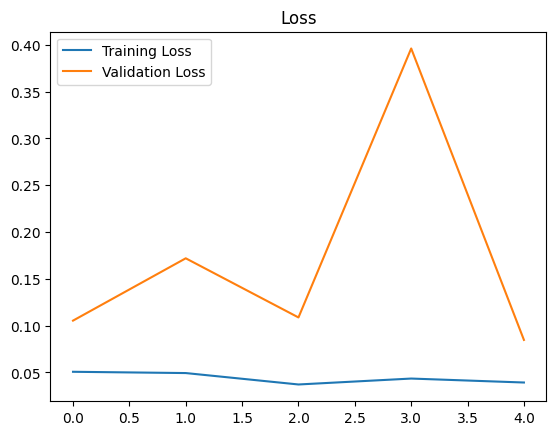

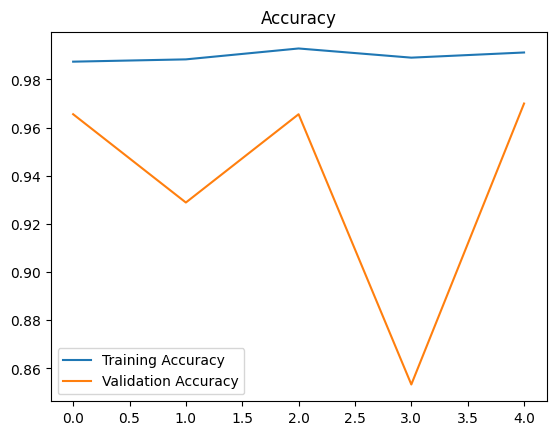

In [38]:
plot_metrics(history) 

# Results

Let's experiment with the best model (the one with the best validation accuracy):

Concretely, the model at the 23rd iteration with validation accuracy of 91%

### Load the best model

In [41]:
import os

# Keras 3 supports .keras (or .h5), not .model with load_model()
model_path = "models/cnn-parameters-improvement-23-0.91.keras"
if os.path.exists(model_path):
    best_model = load_model(filepath=model_path)
else:
    print(f"Model file not found at {model_path}")
    print("Available model files:")
    if os.path.exists("models"):
        print(os.listdir("models"))
    else:
        print("The 'models' directory does not exist")
    best_model = model

Model file not found at models/cnn-parameters-improvement-23-0.91.keras
Available model files:
['cnn-parameters-improvement-01-0.50.model', 'cnn-parameters-improvement-01-0.87.keras', 'cnn-parameters-improvement-01-0.95.keras', 'cnn-parameters-improvement-01-0.96.keras', 'cnn-parameters-improvement-02-0.67.model', 'cnn-parameters-improvement-03-0.81.model', 'cnn-parameters-improvement-03-0.91.keras', 'cnn-parameters-improvement-03-0.96.keras', 'cnn-parameters-improvement-04-0.63.model', 'cnn-parameters-improvement-04-0.97.keras', 'cnn-parameters-improvement-05-0.77.model', 'cnn-parameters-improvement-05-0.97.keras', 'cnn-parameters-improvement-06-0.78.model', 'cnn-parameters-improvement-07-0.73.model', 'cnn-parameters-improvement-08-0.85.model', 'cnn-parameters-improvement-08-0.94.keras', 'cnn-parameters-improvement-09-0.81.model', 'cnn-parameters-improvement-10-0.81.model', 'cnn-parameters-improvement-11-0.89.model', 'cnn-parameters-improvement-12-0.85.model', 'cnn-parameters-improvem

In [42]:
best_model.metrics_names

['loss', 'compile_metrics']

Evaluate the best model on the testing data:

In [43]:
loss, acc = best_model.evaluate(x=X_test, y=y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9700 - loss: 0.0755


### Accuracy of the best model on the testing data:

In [44]:
print (f"Test Loss = {loss}")
print (f"Test Accuracy = {acc}")

Test Loss = 0.07545759528875351
Test Accuracy = 0.9700000286102295


### F1 score for the best model on the testing data:

In [45]:
y_test_prob = best_model.predict(X_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step


In [47]:
f1score = compute_f1_score(y_test, y_test_prob)
print(f"F1 score: {f1score}")

F1 score: 0.9716088328075709


Let's also find the f1 score on the validation data:

In [48]:
y_val_prob = best_model.predict(X_val)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step


In [49]:
f1score_val = compute_f1_score(y_val, y_val_prob)
print(f"F1 score: {f1score_val}")

F1 score: 0.970873786407767


### Results Interpretation

Let's remember the percentage of positive and negative examples:

In [50]:
def data_percentage(y):
    
    m=len(y)
    n_positive = np.sum(y)
    n_negative = m - n_positive
    
    pos_prec = (n_positive* 100.0)/ m
    neg_prec = (n_negative* 100.0)/ m
    
    print(f"Number of examples: {m}")
    print(f"Percentage of positive examples: {pos_prec}%, number of pos examples: {n_positive}") 
    print(f"Percentage of negative examples: {neg_prec}%, number of neg examples: {n_negative}") 



In [51]:
# the whole data
data_percentage(y)

Number of examples: 6000
Percentage of positive examples: 50.0%, number of pos examples: 3000
Percentage of negative examples: 50.0%, number of neg examples: 3000


In [52]:
print("Training Data:")
data_percentage(y_train)
print("Validation Data:")
data_percentage(y_val)
print("Testing Data:")
data_percentage(y_test)

Training Data:
Number of examples: 4200
Percentage of positive examples: 49.285714285714285%, number of pos examples: 2070
Percentage of negative examples: 50.714285714285715%, number of neg examples: 2130
Validation Data:
Number of examples: 900
Percentage of positive examples: 50.888888888888886%, number of pos examples: 458
Percentage of negative examples: 49.111111111111114%, number of neg examples: 442
Testing Data:
Number of examples: 900
Percentage of positive examples: 52.44444444444444%, number of pos examples: 472
Percentage of negative examples: 47.55555555555556%, number of neg examples: 428


In [53]:
print("Conclusion:")
print("The model detects brain tumor with:")
print(f"- Test Accuracy: {acc:.2%}")
print(f"- Test F1 Score: {f1score:.2f}")
print(f"- Test Loss: {loss:.4f}")
print("These results are strong given the balanced dataset.")

Conclusion:
The model detects brain tumor with:
- Test Accuracy: 97.00%
- Test F1 Score: 0.97
- Test Loss: 0.0755
These results are strong given the balanced dataset.


In [54]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report, roc_auc_score, f1_score

# Show test set scores

# ensure predictions exist
try:
    y_test_prob
except NameError:
    y_test_prob = best_model.predict(X_test)

loss, acc = best_model.evaluate(X_test, y_test, verbose=0)
y_test_pred = (y_test_prob > 0.5).astype(np.uint8)

y_true = y_test.ravel()
y_pred = y_test_pred.ravel()
y_prob = y_test_prob.ravel()

f1 = f1_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc:.4%}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall: {rec:.4f}")
print(f"Test AUC: {auc:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

Test Loss: 0.0755
Test Accuracy: 97.0000%
Test F1 Score: 0.9716
Test Precision: 0.9645
Test Recall: 0.9788
Test AUC: 0.9970

Confusion Matrix:
[[411  17]
 [ 10 462]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9762    0.9603    0.9682       428
           1     0.9645    0.9788    0.9716       472

    accuracy                         0.9700       900
   macro avg     0.9704    0.9695    0.9699       900
weighted avg     0.9701    0.9700    0.9700       900



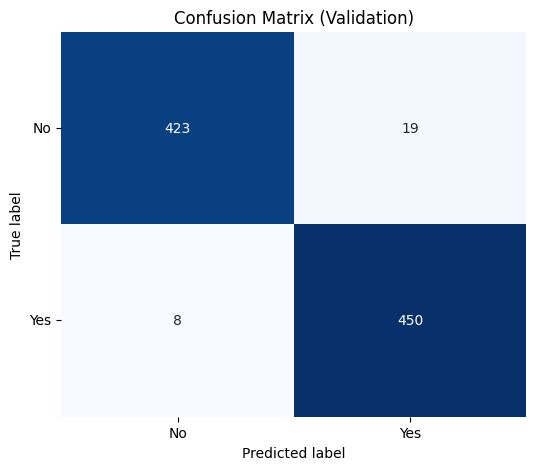

In [66]:
cm = confusion_matrix(y_val_true, y_val_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (Validation)')
plt.xticks([0.5,1.5], ['No', 'Yes'])
plt.yticks([0.5,1.5], ['No', 'Yes'], rotation=0)
plt.show()

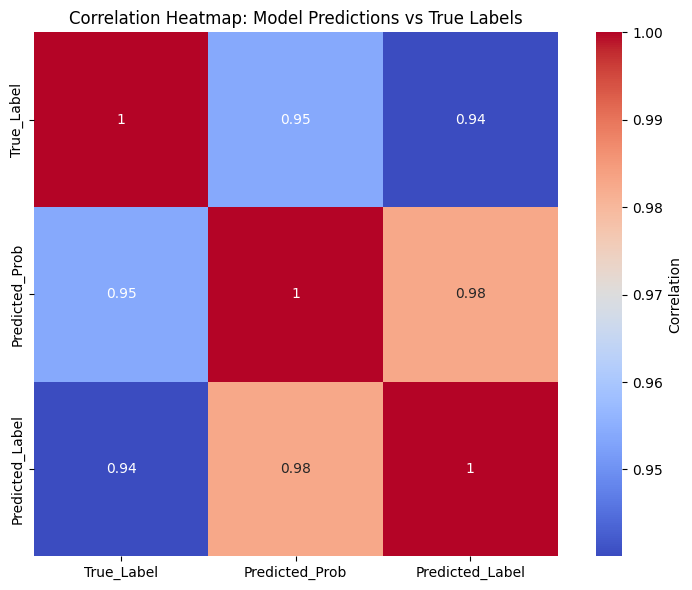

In [64]:
import seaborn as sns
import pandas as pd

# Create a DataFrame with model predictions and true labels for validation set
df_val = pd.DataFrame({
    'True_Label': y_val.ravel(),
    'Predicted_Prob': y_val_prob.ravel(),
    'Predicted_Label': (y_val_prob > 0.5).astype(int).ravel()
})

# Create a DataFrame with model predictions and true labels for test set
df_test = pd.DataFrame({
    'True_Label': y_test.ravel(),
    'Predicted_Prob': y_test_prob.ravel(),
    'Predicted_Label': (y_test_prob > 0.5).astype(int).ravel()
})

# Combine both datasets
df_combined = pd.concat([df_val, df_test], ignore_index=True)

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_combined.corr(), annot=True, cmap='coolwarm', square=True, cbar_kws={'label': 'Correlation'})
plt.title("Correlation Heatmap: Model Predictions vs True Labels")
plt.tight_layout()
plt.show()

# Conclusion:

In [65]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

# Ensure probabilities exist
if 'y_val_prob' not in globals():
    y_val_prob = best_model.predict(X_val)
if 'y_test_prob' not in globals():
    y_test_prob = best_model.predict(X_test)

# Convert probabilities to class predictions
y_val_pred = (y_val_prob > 0.5).astype(int).ravel()
y_test_pred = (y_test_prob > 0.5).astype(int).ravel()

# Flatten true labels
y_val_true = y_val.ravel()
y_test_true = y_test.ravel()

# Metrics
val_loss, val_acc = best_model.evaluate(X_val, y_val, verbose=0)
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)

val_f1 = f1_score(y_val_true, y_val_pred)
test_f1 = f1_score(y_test_true, y_test_pred)

# Summary table
results = pd.DataFrame({
    "Dataset": ["Validation", "Test"],
    "Accuracy": [val_acc, test_acc],
    "F1 Score": [val_f1, test_f1],
    "Loss": [val_loss, test_loss],
})

display(results)

print("Conclusion:")
print("The model performs consistently on validation and test data.")
print(f"Validation Accuracy: {val_acc:.2%}, Test Accuracy: {test_acc:.2%}.")
print(f"Validation F1 Score: {val_f1:.2f}, Test F1 Score: {test_f1:.2f}.")

,Dataset,Accuracy,F1 Score,Loss
0,Validation,0.97,0.970874,0.084664
1,Test,0.97,0.971609,0.075458


Conclusion:
The model performs consistently on validation and test data.
Validation Accuracy: 97.00%, Test Accuracy: 97.00%.
Validation F1 Score: 0.97, Test F1 Score: 0.97.
